In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import kagglehub
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.


In [9]:
import os
print(path)
os.listdir(path)

/kaggle/input/students-performance-in-exams


['StudentsPerformance.csv']

In [10]:
df = pd.read_csv('/kaggle/input/students-performance-in-exams/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
#Before running any code we need to find out the basic info about the dataset.
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)

(1000, 8)
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


In [12]:
print(df['parental level of education'].value_counts())
print(df['lunch'].value_counts())
print(df['test preparation course'].value_counts())

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
test preparation course
none         642
completed    358
Name: count, dtype: int64


In [16]:
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']

In [17]:
total_score

,0
0,218
1,247
2,278
3,148
4,229
...,...
995,282
996,172
997,195
998,223


In [18]:
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [19]:
df[['math score', 'reading score', 'writing score', 'total_score']].head()

,math score,reading score,writing score,total_score
0,72,72,74,218
1,69,90,88,247
2,90,95,93,278
3,47,57,44,148
4,76,78,75,229


In [21]:
df['Scholarship'] = 'None'

df.loc[(df['total_score'] >=200) & (df['lunch'] == 'free/reduced') & (df['parental level of education']) .isin( ['high school',  'some high school ', 'some college']) , 'Scholarship'] = 'Full Scholarship'


In [22]:
df.loc[(df['total_score'] >= 250) & (df['lunch']== 'standard') & (df['parental level of education']).isin([ "bachelor's degree", "associate's degree", "master's degree "]), 'Scholarship'] = 'Partial Scholarship'


In [27]:
df.tail(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,Scholarship
990,male,group E,high school,free/reduced,completed,86,81,75,242,Full Scholarship
991,female,group B,some high school,standard,completed,65,82,78,225,None
992,female,group D,associate's degree,free/reduced,none,55,76,76,207,None
993,female,group D,bachelor's degree,free/reduced,none,62,72,74,208,None
994,male,group A,high school,standard,none,63,63,62,188,None
995,female,group E,master's degree,standard,completed,88,99,95,282,None
996,male,group C,high school,free/reduced,none,62,55,55,172,None
997,female,group C,high school,free/reduced,completed,59,71,65,195,None
998,female,group D,some college,standard,completed,68,78,77,223,None
999,female,group D,some college,free/reduced,none,77,86,86,249,Full Scholarship


In [33]:
print(df['Scholarship'].value_counts())

Scholarship
None                   899
Full Scholarship        51
Partial Scholarship     50
Name: count, dtype: int64


In [28]:
full_scholarship_winners= df[df['Scholarship'] == 'Full Scholarship'].sort_values(by=['total_score', 'math score'], ascending=False).head(30)

In [37]:
print(f"Full Scholarship Winners: {len(full_scholarship_winners)}")
full_scholarship_winners

Full Scholarship Winners: 30


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,Scholarship
689,male,group E,some college,free/reduced,none,93,90,83,266,Full Scholarship
463,female,group C,some college,free/reduced,none,77,90,91,258,Full Scholarship
695,female,group D,some college,free/reduced,none,79,89,86,254,Full Scholarship
468,female,group A,high school,free/reduced,completed,77,88,85,250,Full Scholarship
999,female,group D,some college,free/reduced,none,77,86,86,249,Full Scholarship
728,female,group D,high school,free/reduced,none,73,92,84,249,Full Scholarship
161,female,group E,some college,free/reduced,completed,75,88,85,248,Full Scholarship
86,female,group C,some college,free/reduced,none,76,83,88,247,Full Scholarship
782,female,group B,high school,free/reduced,completed,76,85,82,243,Full Scholarship
990,male,group E,high school,free/reduced,completed,86,81,75,242,Full Scholarship


In [34]:
Partial_Scholarship_winners= df[df['Scholarship']=='Partial Scholarship'].sort_values(by= ['total_score', 'math score'], ascending=False).head(20)

In [36]:
Partial_Scholarship_winners

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,Scholarship
458,female,group E,bachelor's degree,standard,none,100,100,100,300,Partial Scholarship
916,male,group E,bachelor's degree,standard,completed,100,100,100,300,Partial Scholarship
962,female,group E,associate's degree,standard,none,100,100,100,300,Partial Scholarship
114,female,group E,bachelor's degree,standard,completed,99,100,100,299,Partial Scholarship
165,female,group C,bachelor's degree,standard,completed,96,100,100,296,Partial Scholarship
717,female,group C,associate's degree,standard,completed,96,96,99,291,Partial Scholarship
594,female,group C,bachelor's degree,standard,completed,92,100,99,291,Partial Scholarship
855,female,group B,bachelor's degree,standard,none,97,97,96,290,Partial Scholarship
970,female,group D,bachelor's degree,standard,none,89,100,100,289,Partial Scholarship
886,female,group E,associate's degree,standard,completed,93,100,95,288,Partial Scholarship


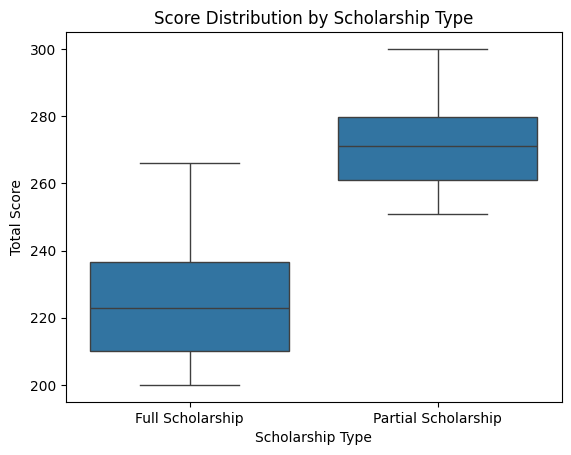

In [38]:
sns.boxplot(data=df[df['Scholarship'] != 'None'],
            x='Scholarship', y='total_score')
plt.title('Score Distribution by Scholarship Type')
plt.xlabel('Scholarship Type')
plt.ylabel('Total Score')
plt.show()

This box plot shows that 50% of the students scored between 215 and 236, with the lowest scoring 200 and the highest 266. Also, we can see that 50% of the students scored between 260 and 278, with lowest scoring 250 and the highest scoring 300.

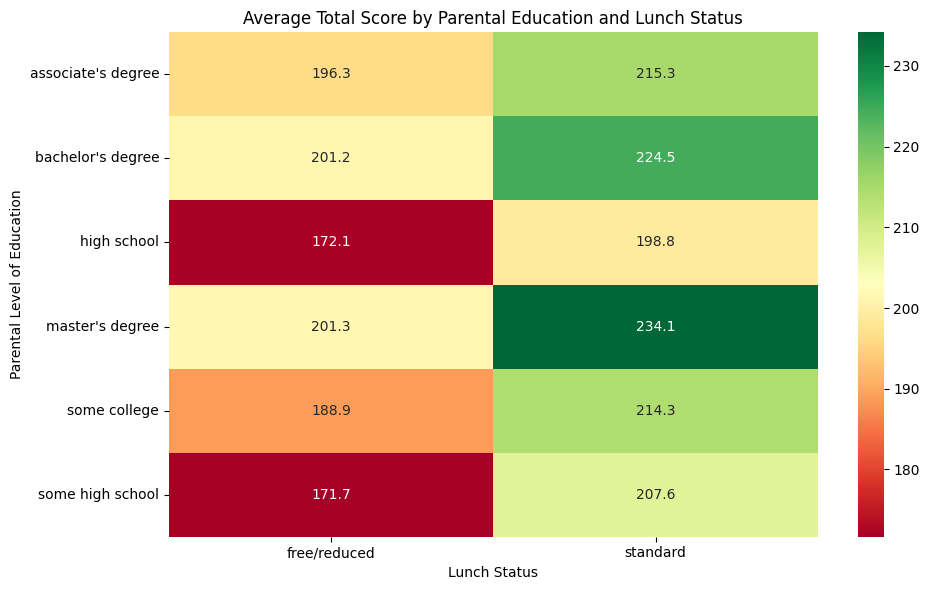

In [40]:
heatmap_data = df.groupby(['parental level of education', 'lunch'])['total_score'].mean().unstack()

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn')
plt.title('Average Total Score by Parental Education and Lunch Status')
plt.xlabel('Lunch Status')
plt.ylabel('Parental Level of Education')
plt.tight_layout()
plt.show()

The heatmap revealed that the combination of low parental education AND free/reduced lunch created a compounding disadvantage — students facing both factors scored up to 62 points lower on average than students with neither disadvantage. This validated our scholarship design — these students need and deserve more support.
